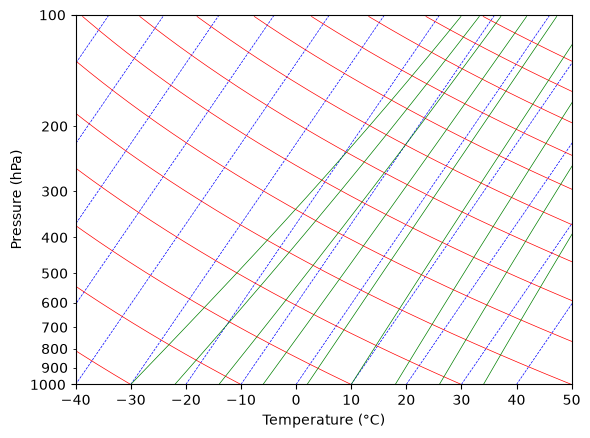

In [ ]:
#hi this is rylans skewt thing

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

########## isolating my constants #############
g = 9.81 # m/s^2
Cp = 1004 # J/kgK 
Rd = 287 # J/kgK
Lv = 2.5e6 # J/kg
Rv = 461.5 # J/kgK

###############################################

fig, ax = plt.subplots() # generating new figure

ax.semilogy()
ax.set_ylim(1000, 100)
ax.yaxis.set_minor_formatter(mticker.ScalarFormatter())
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_ylabel('Pressure (hPa)')

ax.set_xlim(-40, 50)
ax.set_xlabel('Temperature (°C)')



def skewT(temp, pres, skew=-20):
#’’’
#Skews the temperature axis for a SkewT plot.
##temp: temperature values (deg C)
##pres: pressure values (hPa) whyd this part have to be commented out
###skew: amount of skew (default of -20)
    return (temp) + skew * np.log(pres/1000.0)

#now how to do isotherms

for i in range(-80, 50, 10):
    ax.plot(skewT(np.array([i, i]), np.array([1000, 100])), np.array([1000, 100]), color='blue', linewidth=0.5, linestyle='--')


# uhh lets try dry adiabats?

#we in pressure space, so i guess lets plot potential temperature as the dry adiabats

def isentrope(theta0):

    theta = theta0 + 273.15 # convert to kelvin
    p0 = 1000
    pf = 100
    oneisentrope = np.arange(p0, pf, -1) # basically making for one single isentrope, the pressure values from 1000 to 100 hPa and finding 
    # temp given pressure and potential temp 

    return theta * (oneisentrope/p0)**(Rd/Cp) - 273.15 # basically solving for temperature from theta

for thetaq in range(-30, 240, 20):
    ax.plot(skewT(isentrope(thetaq), np.arange(1000, 100, -1)), np.arange(1000, 100, -1), color='red', linewidth=0.5)

#now for the moist adiabats. cant quite use the one in the notes because thats relative to z not p

def moist(T): # for an initial temperature
    p0 = 1000 # hPa
    Tk = T + 273.15 # converting to kelvin 
    pressure = p0

    finaltemps = []

    while pressure > 100:

        es = 6.112 * np.exp(17.67 * (Tk - 273.15)/(Tk - 29.65)) # saturation vapor pressure in hPa

        rs = (Rd/Rv) * (es/(pressure - es)) # saturation mixing ratio in kg/kg

        gamma = (Rd*T/(Cp*pressure))*((1+(Lv*rs/(Rd*Tk)))/(1+(Lv**2*rs/(Cp*Rv*Tk**2)))) # moist adiabatic lapse rate in K/hPa
        finaltemps.append(Tk - 273.15) # appending the temperature in celsius to the list
        Tk -= gamma # updating temperature in kelvin
        pressure -= 1
    return finaltemps


for T0 in range(-30, 40, 8):
    ax.plot(skewT(moist(T0), np.arange(1000, 100, -1)), np.arange(1000, 100, -1), color='green', linewidth=0.5)